# Pneumonia Detection using Transfer Learning with ResNet50V2

### Deep Learning for Chest X-ray Classification

This notebook presents a binary image classification model for detecting pneumonia from chest X-ray images using Transfer Learning with a pretrained ResNet50V2 model.

# Project Overview

Pneumonia is one of the leading causes of death worldwide, especially among children and elderly people. Early diagnosis from chest X-ray images can significantly improve treatment outcomes.

In this project, a Transfer Learning approach is used by leveraging a pretrained ResNet50V2 model trained on ImageNet. The objective is to classify chest X-ray images into two categories:

- PNEUMONIA
- NORMAL

The project also investigates how class imbalance affects model performance and evaluates several techniques to improve generalization.

# Objectives

The objectives of this notebook are:

- Load and preprocess chest X-ray images.
- Perform image preprocessing and resizing.
- Build a Transfer Learning model using ResNet50V2.
- Train the last 30 layers of base model ResNet50V2 (Fine Tuning)
- Evaluate model performance.
- Analyze class imbalance.
- Investigate overfitting and generalization.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

# Import Required Libraries

The following libraries are used for:

- Data processing
- Image visualization
- Deep learning
- Model evaluation

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.applications import ResNet50V2
from keras.layers import GlobalAveragePooling2D, Dropout, Dense
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast

import sklearn
from sklearn.utils.class_weight import compute_class_weight
import cv2
import random

# Loading Dataset

The dataset is loaded from Kaggle.

Each image is:

- Read in grayscale
- Resized to 224 × 224
- Assigned its corresponding class label

In [3]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia


In [4]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 224
def get_training_data(data_dir):
    data = []

    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(
                    os.path.join(path, img),
                    cv2.IMREAD_GRAYSCALE
                )

                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])

            except Exception as e:
                print(e)

    return data      # ← not np.array(data)

In [5]:
train_df = get_training_data(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train"
)

test_df = get_training_data(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test"
)

val_df = get_training_data(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val"
)

OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'

OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'

OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'

OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'



# Dataset

Dataset: Chest X-Ray Pneumonia Dataset

Classes:
- NORMAL
- PNEUMONIA

Training Images:
- Pneumonia : 3875
- Normal : 1341

Testing Images:
- Pneumonia : 390
- Normal : 234

Image Format:
- JPEG

Input Size:a
- 224 × 224

In [6]:
from random import shuffle

shuffle(train_df)
shuffle(test_df)
shuffle(val_df)

X_train = []
y_train = []

for image, label in train_df:
    X_train.append(image)
    y_train.append(label)

X_test = []
y_test = []

for image, label in test_df:
    X_test.append(image)
    y_test.append(label)

X_val = []
y_val = []

for image, label in val_df:
    X_val.append(image)
    y_val.append(label)

# Data Preprocessing

The preprocessing pipeline consists of:

- Resizing images
- Converting grayscale images to RGB
- Creating NumPy arrays
- Splitting features and labels
- Applying preprocessing required for ResNet50V2

In [7]:
import numpy as np

X_train = np.array(X_train)
X_test = np.array(X_test)
X_val = np.array(X_val)

y_train = np.array(y_train)
y_test = np.array(y_test)
y_val = np.array(y_val)

In [8]:
X_train = X_train.reshape(-1, 224, 224, 1)
X_test = X_test.reshape(-1, 224, 224, 1)
X_val = X_val.reshape(-1, 224, 224, 1)

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

In [10]:
print(y_train.shape)
print(np.unique(y_train))

(5216,)
[0 1]


# Visualizing Sample Images

Before training, we inspect several chest X-ray images from both classes to ensure that the dataset has been loaded correctly.

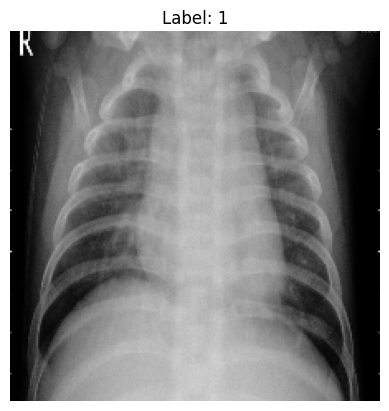

In [11]:
plt.imshow(X_train[0].reshape(224, 224), cmap='gray')
plt.title(f"Label: {y_train[12]}")
plt.axis('off')
plt.show()

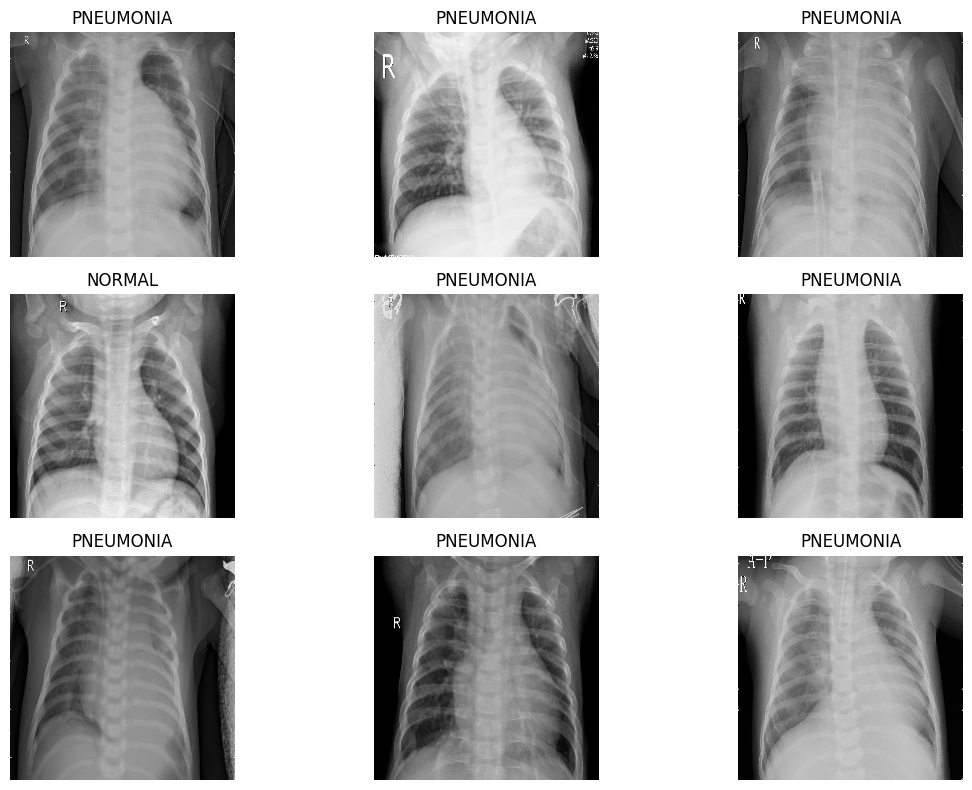

In [12]:
plt.figure(figsize=(12, 8))

for i in range(9):
    idx = random.randint(0, len(X_train) - 1)

    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[idx].reshape(224, 224), cmap='gray')
    plt.title(labels[y_train[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# now converting grayscale to RGB for ResNet Use:
X_train = np.repeat(X_train, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)

print(X_train.shape)

(5216, 224, 224, 3)


In [14]:
from tensorflow.keras.applications.resnet_v2 import preprocess_input

X_train = preprocess_input(X_train.astype("float32"))
X_test = preprocess_input(X_test.astype("float32"))
X_val = preprocess_input(X_val.astype("float32"))

# Training and Validation Split

The original validation dataset contained only 16 images, which is insufficient for reliable evaluation.

Therefore, 15% of the training dataset is used as a validation set using stratified sampling to preserve class distribution.

In [15]:
# Validation Data is very less

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

# Data Augmentation

To improve model generalization, data augmentation is applied during training.

Transformations include:

- Horizontal Flip
- Rotation
- Zoom
- Contrast Adjustment

Data augmentation helps reduce overfitting by exposing the model to different variations of the same image.

In [16]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.1)
])

I0000 00:00:1785583300.907896      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785583300.911188      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [17]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.6730944427573641), 1: np.float64(1.9442982456140352)}


In [18]:
# strategy for model training - Kaggle GPU T4 X2

strategy = tf.distribute.MirroredStrategy()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


# Transfer Learning

ResNet50V2 pretrained on ImageNet is used as the feature extractor.

Stage 1:

- Freeze all convolutional layers except last 30.
- Train last 30 layers along with custom classification head.

In [19]:
with strategy.scope() : 
    
    # ResNet50V2 expects inputs scaled between -1 and 1, handled automatically inside the layer
    base_model = ResNet50V2(
        weights='imagenet', 
        include_top=False,
        input_shape=(224, 224, 3)
    )
    
    # allowing training for last 30 layers
    base_model.trainable = True
    
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation="sigmoid")(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,679,681 (94.15 MB)

 Trainable params: 15,558,401 (59.35 MB)

 Non-trainable params: 9,121,280 (34.79 MB)

In [20]:
print(model.input_shape)
print(X_train.shape)

print(model.output_shape)
print(y_train.shape)

(None, 224, 224, 3)
(4433, 224, 224, 3)
(None, 1)
(4433,)


In [21]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "best_resnet50v2.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    class_weight = class_weights,
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.8109 - loss: 1.0316
Test Accuracy: 0.8109
Test Loss: 1.0316


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

y_pred_proba = model.predict(X_test).ravel()
y_pred_fixed = (y_pred_proba > 0.35).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ResNet50V2 (AUC = {auc:.4f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Pneumonia Detection")
plt.legend()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step
              precision    recall  f1-score   support

           0       0.77      0.99      0.87       390
           1       0.97      0.51      0.67       234

    accuracy                           0.81       624
   macro avg       0.87      0.75      0.77       624
weighted avg       0.85      0.81      0.79       624

[[386   4]
 [114 120]]


# Confusion Matrix Analysis

The confusion matrix provides a detailed understanding of prediction performance.

The model correctly identifies almost all pneumonia cases but incorrectly classifies many normal chest X-rays as pneumonia.

The ResNet50V2 model achieved a test accuracy of 81%, correctly identifying 386 out of 390 pneumonia cases (99% recall) but only 114 out of 234 normal cases (51% recall). The model exhibited a strong bias toward predicting pneumonia, resulting in 120 normal images being misclassified as pneumonia. These results indicate that, despite excellent pneumonia detection, the model struggled to generalize to the normal class due to class imbalance and overfitting.

# Challenges Encountered

Several challenges were observed during this project:

- Dataset imbalance
- Overfitting
- Poor generalization on unseen data
- High false-positive rate for NORMAL images

Experiments such as class weighting and data augmentation were evaluated but did not significantly improve test performance.

# Conclusion

This project demonstrates the effectiveness of Transfer Learning for medical image classification.

Although the finetuning ResNet50V2 model achieved high training and validation accuracy, its performance on unseen test data indicates limited generalization.